# Exploratory Data Analysis

This notebook performs exploratory data analysis on cleaned NHL shot data.

## Sections:
1. Basic feature engineering (distance, angle)
2. Basic statistics
3. Goal rate analysis by various factors
4. Visualizations (heatmaps, scatter plots)
5. Correlation analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle
import sys

# Add src to path
sys.path.append('../../')
from src.features.feature_engineering import calculate_shot_distance, calculate_shot_angle

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


## Load Cleaned Data


In [2]:
# Load cleaned data
df_shots_clean = pd.read_parquet("../../data/processed/cleaned_shots.parquet")

print(f"Data shape: {df_shots_clean.shape}")
print(f"Total shots: {len(df_shots_clean):,}")
print(f"Total goals: {df_shots_clean['is_goal'].sum():,}")
df_shots_clean.head()


Data shape: (680581, 29)
Total shots: 680,581
Total goals: 36,940


,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,assist1PlayerId,assist1PlayerTotal,...,scoringPlayerId,scoringPlayerTotal,shootingPlayerId,shotType,xCoord,yCoord,zoneCode,period,periodType,is_goal
0,10,00:25,19:35,1551,right,505,goal,11,8477015.0,1.0,...,8480801.0,1.0,NaN,tip-in,85.0,-1.0,O,1,REG,1
1,12,00:38,19:22,1551,right,507,missed-shot,15,None,None,...,NaN,NaN,8479458.0,slap,28.0,-37.0,O,1,REG,0
2,15,01:31,18:29,1451,right,506,shot-on-goal,28,None,None,...,NaN,NaN,8476853.0,snap,32.0,2.0,O,1,REG,0
3,50,01:39,18:21,1451,right,508,blocked-shot,32,None,None,...,NaN,NaN,8477341.0,unknown,74.0,-7.0,D,1,REG,0
4,18,01:58,18:02,1451,right,507,missed-shot,33,None,None,...,NaN,NaN,8478483.0,wrist,46.0,16.0,O,1,REG,0


## Basic Feature Engineering

Calculate distance and angle features.


In [3]:
# Calculate shot distance
df_shots_clean['distance'] = calculate_shot_distance(df_shots_clean)

# Calculate shot angle
df_shots_clean['angle'] = calculate_shot_angle(df_shots_clean)

# Display sample
print("Sample with distance and angle:")
df_shots_clean[['xCoord', 'yCoord', 'distance', 'angle']].head(10)


Sample with distance and angle:


,xCoord,yCoord,distance,angle
0,85.0,-1.0,4.123106,-14.036243
1,28.0,-37.0,71.344236,-31.239215
2,32.0,2.0,57.035077,2.009554
3,74.0,-7.0,16.552945,-25.016893
4,46.0,16.0,45.880279,20.409883
5,64.0,4.0,25.317978,9.090277
6,63.0,-6.0,26.683328,-12.994617
7,59.0,20.0,36.055513,33.690068
8,86.0,-4.0,5.000000,-53.130102
9,42.0,29.0,55.226805,31.675469


## Basic Statistics


In [4]:
print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(f"\nTotal number of shots: {len(df_shots_clean):,}")
print(f"Total Number of Goals: {df_shots_clean['is_goal'].sum():,}")
print(f"Overall Goal Rate: {df_shots_clean['is_goal'].mean():.2%}")
print(f"\nShot Type Distribution:")
print(df_shots_clean['shotType'].value_counts())
print(f"\nShot Outcome Distribution:")
print(df_shots_clean['typeDescKey'].value_counts())


BASIC STATISTICS

Total number of shots: 680,581
Total Number of Goals: 36,940
Overall Goal Rate: 5.43%

Shot Type Distribution:
shotType
wrist           278415
unknown         170897
snap             69777
slap             67839
tip-in           38485
backhand         37531
deflected        11657
wrap-around       4239
poke               861
bat                716
between-legs       148
cradle              16
Name: count, dtype: int64

Shot Outcome Distribution:
typeDescKey
shot-on-goal    330102
blocked-shot    170845
missed-shot     142694
goal             36940
Name: count, dtype: int64


## Goal Rate by Distance


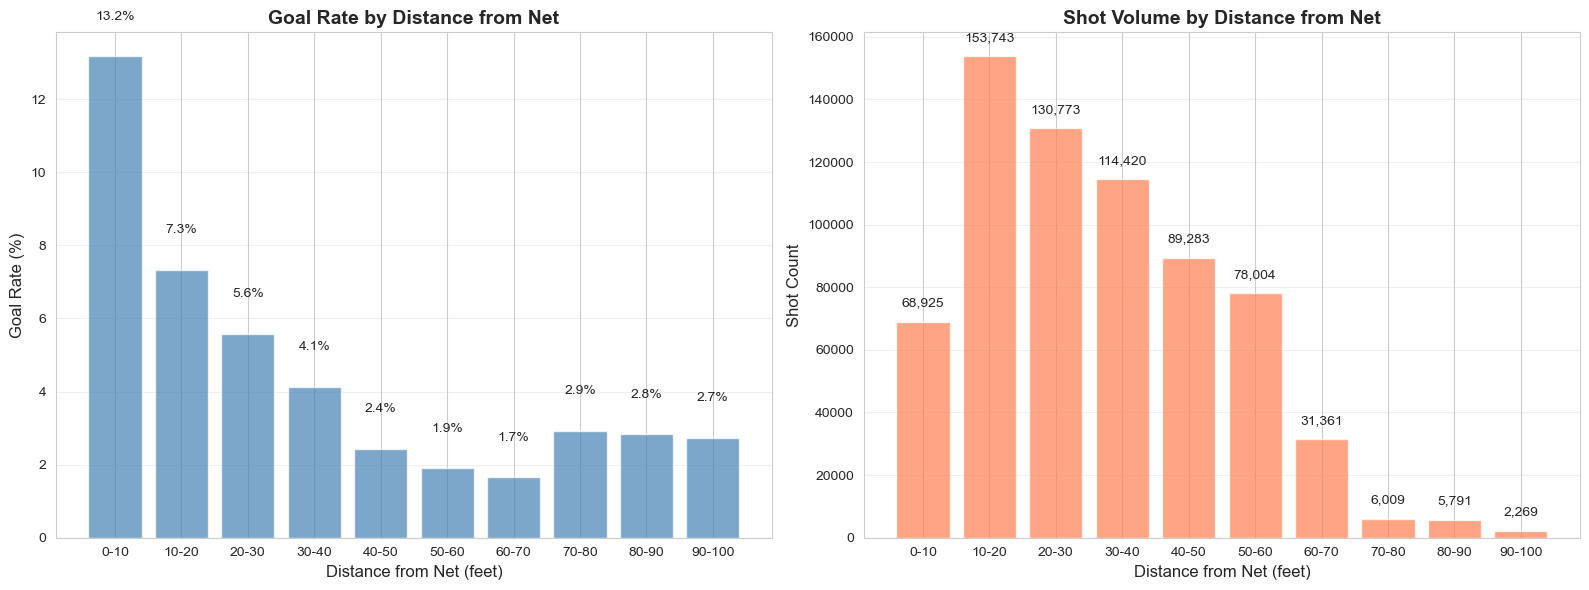


Goal Rate by Distance:
  distance_bin  goal_rate  shot_count
0         0-10   0.131737       68925
1        10-20   0.073278      153743
2        20-30   0.055738      130773
3        30-40   0.041348      114420
4        40-50   0.024316       89283
5        50-60   0.018986       78004
6        60-70   0.016549       31361
7        70-80   0.029289        6009
8        80-90   0.028320        5791
9       90-100   0.027325        2269


In [5]:
# Create distance bins
df_shots_clean['distance_bin'] = pd.cut(df_shots_clean['distance'],
                    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
                    labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100'])

# Calculate goal rate by distance bin
distance_goal_rate = df_shots_clean.groupby('distance_bin', observed=True)['is_goal'].agg(['mean', 'count'])
distance_goal_rate.columns = ['goal_rate', 'shot_count']
distance_goal_rate = distance_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Goal rate by distance
ax1.bar(distance_goal_rate['distance_bin'].astype(str),
       distance_goal_rate['goal_rate'] * 100,
       color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Distance from Net (feet)', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Distance from Net', fontsize = 14, fontweight = 'bold')
ax1.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(distance_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
             ha = 'center', fontsize = 10)

# Shot count by distance
ax2.bar(distance_goal_rate['distance_bin'].astype(str),
        distance_goal_rate['shot_count'],
        color='coral', alpha = 0.7)
ax2.set_xlabel('Distance from Net (feet)', fontsize = 12)
ax2.set_ylabel('Shot Count', fontsize = 12)
ax2.set_title('Shot Volume by Distance from Net', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(distance_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Distance:")
print(distance_goal_rate)


## Goal Rate by Angle


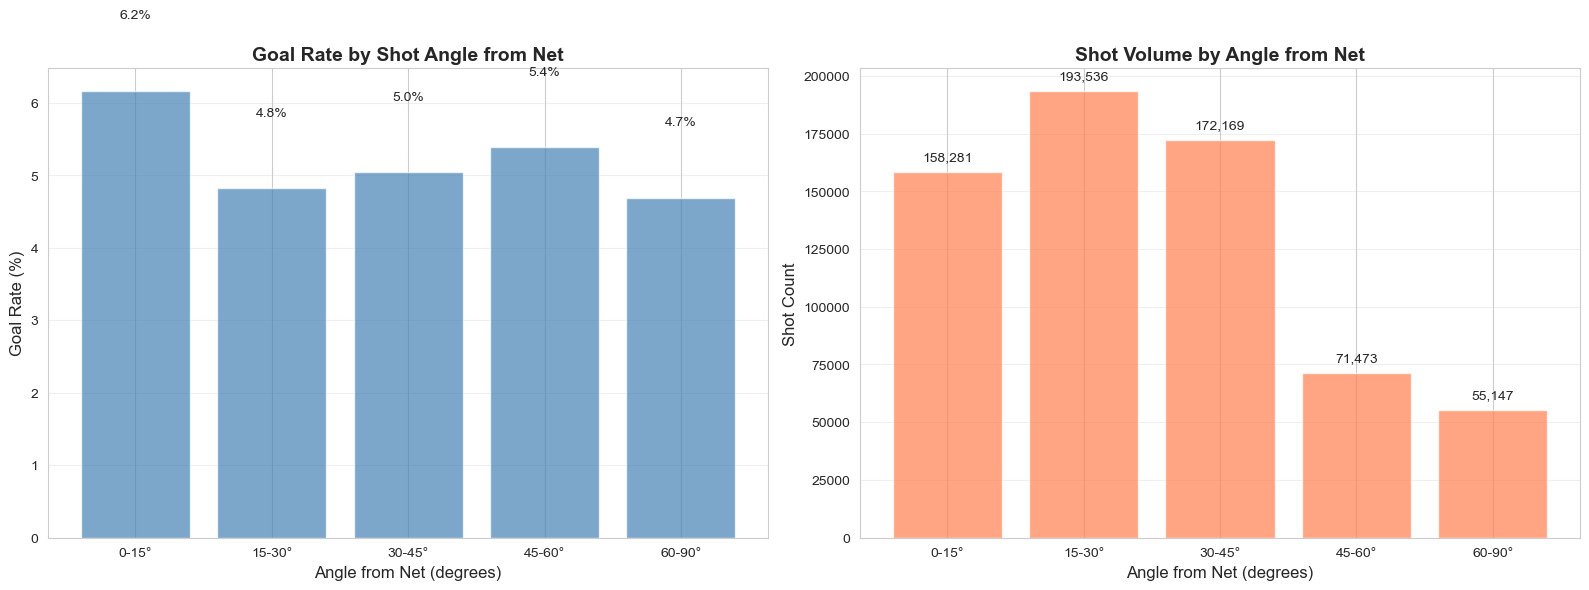


Goal Rate by Angle:
  angle_bin  goal_rate  shot_count
0     0-15°   0.061662      158281
1    15-30°   0.048187      193536
2    30-45°   0.050410      172169
3    45-60°   0.053853       71473
4    60-90°   0.046893       55147


In [6]:
# Create angle bins (absolute value)
df_shots_clean['angle_abs'] = df_shots_clean['angle'].abs()
df_shots_clean['angle_bin'] = pd.cut(df_shots_clean['angle_abs'],
                                     bins=[0, 15, 30, 45, 60, 90],
                                     labels=['0-15°', '15-30°', '30-45°', '45-60°','60-90°'])

# Calculate goal rate by angle bin
angle_goal_rate = df_shots_clean.groupby('angle_bin', observed=True)['is_goal'].agg(['mean', 'count'])
angle_goal_rate.columns = ['goal_rate', 'shot_count']
angle_goal_rate = angle_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Goal rate by angle
ax1.bar(angle_goal_rate['angle_bin'].astype(str),
        angle_goal_rate['goal_rate'] * 100,
        color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Angle from Net (degrees)', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Shot Angle from Net', fontsize = 14, fontweight = 'bold')
ax1.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(angle_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
              ha='center', fontsize = 10)

# Shot count by angle
ax2.bar(angle_goal_rate['angle_bin'].astype(str),
        angle_goal_rate['shot_count'],
        color='coral', alpha = 0.7)
ax2.set_xlabel('Angle from Net (degrees)', fontsize = 12)
ax2.set_ylabel('Shot Count', fontsize = 12)
ax2.set_title('Shot Volume by Angle from Net', fontsize = 14, fontweight = 'bold')
ax2.grid(axis='y', alpha = 0.3)
for i, (idx, row) in enumerate(angle_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Angle:")
print(angle_goal_rate)


## Goal Rate by Shot Type


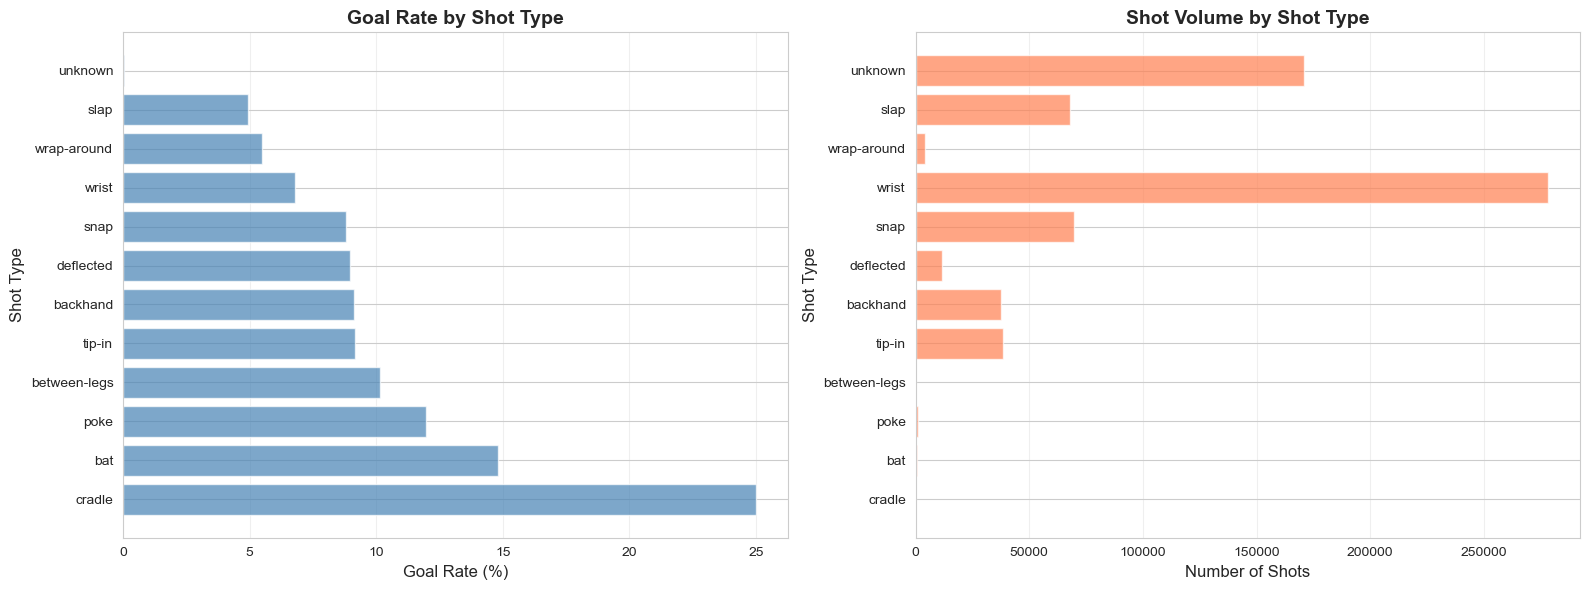


Goal Rate by Shot Type:
        shotType  goal_rate  shot_count
0         cradle   0.250000          16
1            bat   0.148045         716
2           poke   0.119628         861
3   between-legs   0.101351         148
4         tip-in   0.091698       38485
5       backhand   0.091311       37531
6      deflected   0.089646       11657
7           snap   0.088081       69777
8          wrist   0.068017      278415
9    wrap-around   0.054966        4239
10          slap   0.049323       67839
11       unknown   0.000287      170897


In [7]:
shot_type_goal_rate = df_shots_clean.groupby('shotType')['is_goal'].agg(['mean', 'count'])
shot_type_goal_rate.columns = ['goal_rate', 'shot_count']
shot_type_goal_rate = shot_type_goal_rate.sort_values(by='goal_rate', ascending=False).reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Goal rate by shot type
ax1.barh(shot_type_goal_rate['shotType'],
         shot_type_goal_rate['goal_rate'] * 100,
         color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Goal Rate (%)', fontsize = 12)
ax1.set_ylabel('Shot Type', fontsize = 12)
ax1.set_title('Goal Rate by Shot Type', fontsize = 14, fontweight = 'bold')
ax1.grid(axis = 'x', alpha = 0.3)

# Shot count by shot type
ax2.barh(shot_type_goal_rate['shotType'],
         shot_type_goal_rate['shot_count'],
         color = 'coral', alpha = 0.7)
ax2.set_xlabel('Number of Shots', fontsize = 12)
ax2.set_ylabel('Shot Type', fontsize = 12)
ax2.set_title('Shot Volume by Shot Type', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'x', alpha = 0.3)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Shot Type:")
print(shot_type_goal_rate)


## Goal Rate by Zone


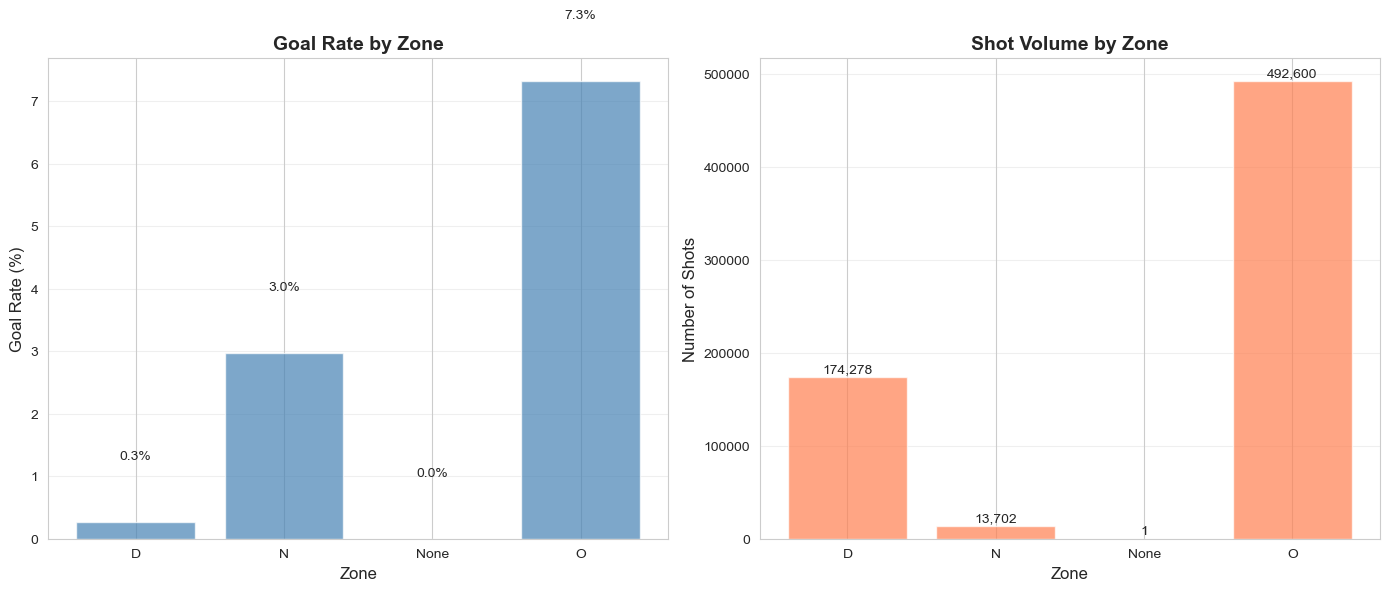


Goal Rate by Zone:
  zoneCode  goal_rate  shot_count
0        D   0.002697      174278
1        N   0.029777       13702
2     None   0.000000           1
3        O   0.073207      492600


In [8]:
zone_goal_rate = df_shots_clean.groupby('zoneCode')['is_goal'].agg(['mean', 'count'])
zone_goal_rate.columns = ['goal_rate', 'shot_count']
zone_goal_rate = zone_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Goal rate by zone
ax1.bar(zone_goal_rate['zoneCode'],
        zone_goal_rate['goal_rate'] * 100,
        color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Zone', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Zone', fontsize =14, fontweight = 'bold')
ax1.grid(axis='y', alpha = 0.3)
for i, (idx, row) in enumerate(zone_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
             ha='center', fontsize = 10)

# Shot count by zone
ax2.bar(zone_goal_rate['zoneCode'],
        zone_goal_rate['shot_count'],
        color='coral', alpha = 0.7)
ax2.set_xlabel('Zone', fontsize = 12)
ax2.set_ylabel('Number of Shots', fontsize = 12)
ax2.set_title('Shot Volume by Zone', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(zone_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Zone:")
print(zone_goal_rate)


## Goal Rate by Period


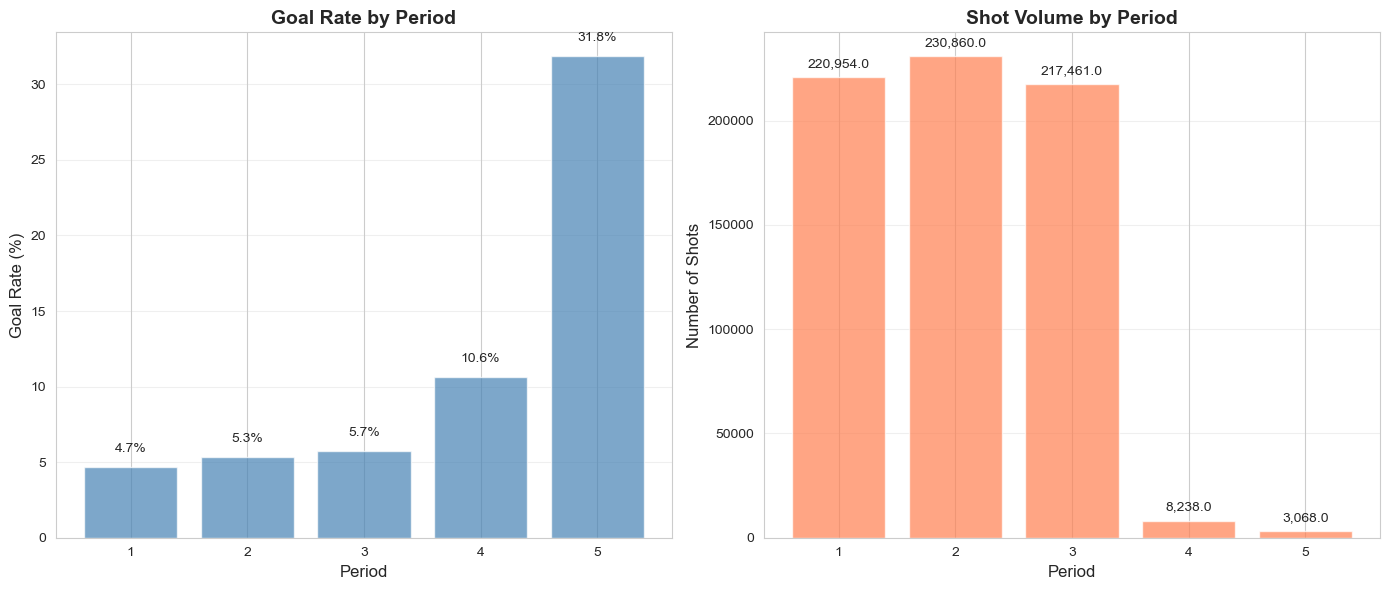


Goal Rate by Period:
   period  goal_rate  shot_count
0       1   0.046987      220954
1       2   0.053214      230860
2       3   0.057109      217461
3       4   0.106458        8238
4       5   0.318449        3068


In [9]:
period_goal_rate = df_shots_clean.groupby('period')['is_goal'].agg(['mean', 'count'])
period_goal_rate.columns = ['goal_rate', 'shot_count']
period_goal_rate = period_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

# Goal rate by period
ax1.bar(period_goal_rate['period'].astype(str),
        period_goal_rate['goal_rate'] * 100,
        color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Period', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Period', fontsize = 14, fontweight = 'bold')
ax1.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(period_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
             ha = 'center', fontsize = 10)

# Shot count by period
ax2.bar(period_goal_rate['period'].astype(str),
        period_goal_rate['shot_count'],
        color = 'coral', alpha = 0.7)
ax2.set_xlabel('Period', fontsize = 12)
ax2.set_ylabel('Number of Shots', fontsize = 12)
ax2.set_title('Shot Volume by Period', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(period_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Period:")
print(period_goal_rate)


## Shot Location Heat Map


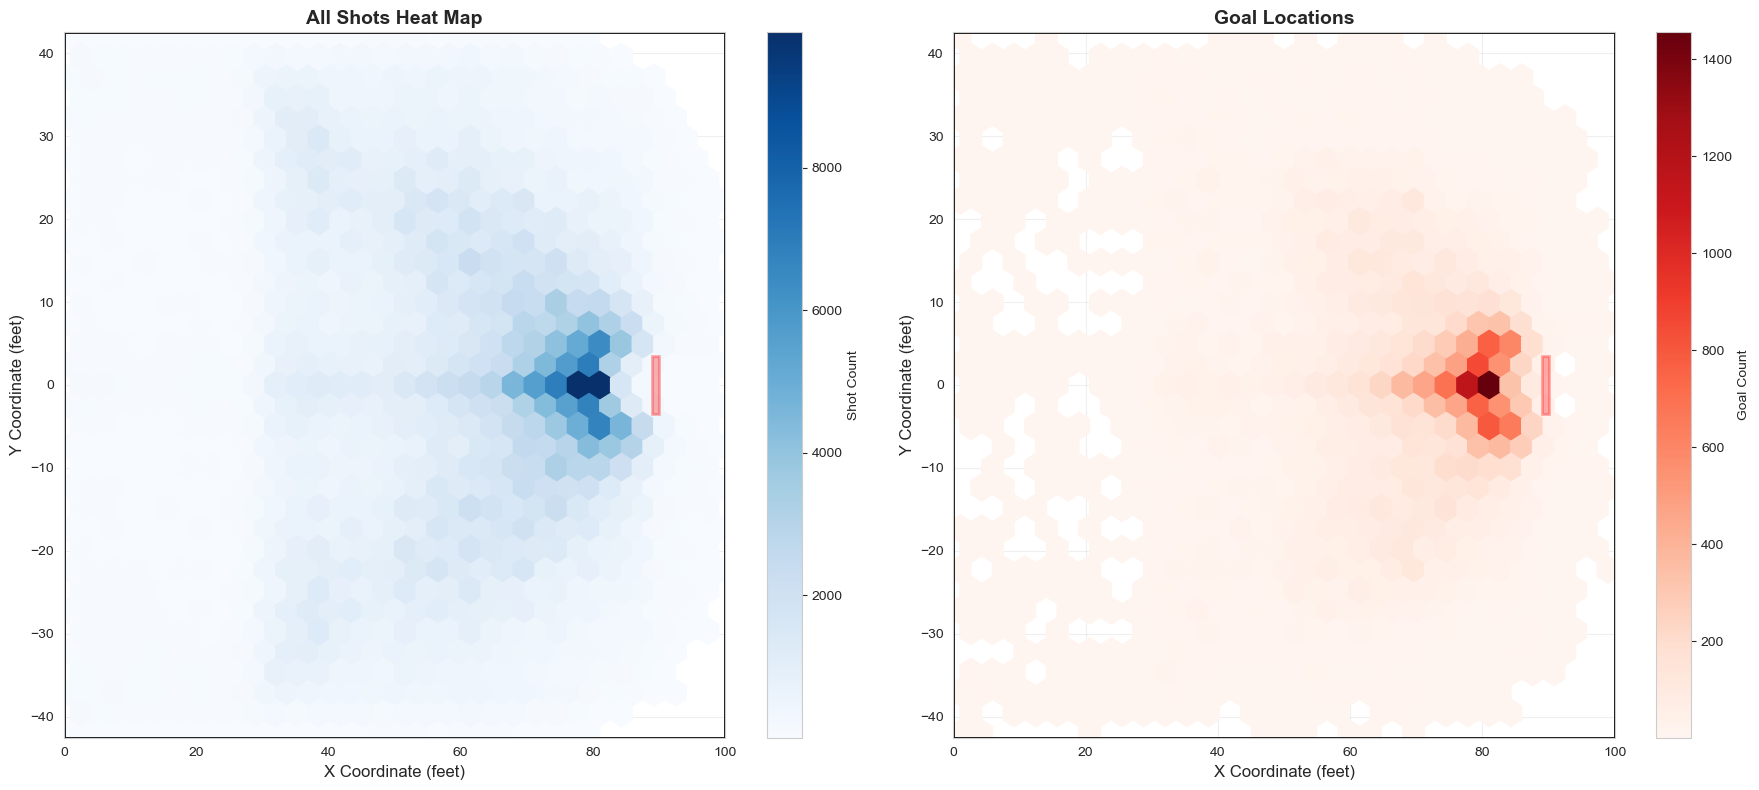

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (18, 8))

# Filter to offensive zone shots (xCoord > 0)
offensive_shots = df_shots_clean[df_shots_clean['xCoord'] > 0].copy()

# All shots heatmap
h1 = ax1.hexbin(offensive_shots['xCoord'], offensive_shots['yCoord'],
                gridsize = 30, cmap = 'Blues', mincnt = 1)
ax1.set_xlabel('X Coordinate (feet)', fontsize = 12)
ax1.set_ylabel('Y Coordinate (feet)', fontsize = 12)
ax1.set_title('All Shots Heat Map', fontsize = 14, fontweight = 'bold')
ax1.set_xlim(0, 100)
ax1.set_ylim(-42.5, 42.5)
ax1.grid(True, alpha = 0.3)
plt.colorbar(h1, ax = ax1, label = 'Shot Count')

# Draw rink outline
rink_rect = Rectangle((0, -42.5), 100, 85, linewidth = 2, edgecolor = 'black', fill = False)
ax1.add_patch(rink_rect)
goal_line = Rectangle((89, -3.5), 1, 7, linewidth = 2, edgecolor = 'red', fill = True, facecolor = 'red', alpha = 0.3)
ax1.add_patch(goal_line)

# Goals heatmap
goals = offensive_shots[offensive_shots['is_goal'] == 1]
h2 = ax2.hexbin(goals['xCoord'], goals['yCoord'],
                gridsize = 30, cmap = 'Reds', mincnt = 1)
ax2.set_xlabel('X Coordinate (feet)', fontsize = 12)
ax2.set_ylabel('Y Coordinate (feet)', fontsize = 12)
ax2.set_title('Goal Locations', fontsize = 14, fontweight = 'bold')
ax2.set_xlim(0, 100)
ax2.set_ylim(-42.5, 42.5)
ax2.grid(True, alpha = 0.3)
plt.colorbar(h2, ax = ax2, label = 'Goal Count')

# Draw rink outline
rink_rect2 = Rectangle((0, -42.5), 100, 85, linewidth = 2, edgecolor = 'black', fill = False)
ax2.add_patch(rink_rect2)
goal_line2 = Rectangle((89, -3.5), 1, 7, linewidth = 2, edgecolor = 'red', fill = True, facecolor = 'red', alpha = 0.3)
ax2.add_patch(goal_line2)

plt.tight_layout()
plt.show()


## Distance vs Angle Scatter Plot


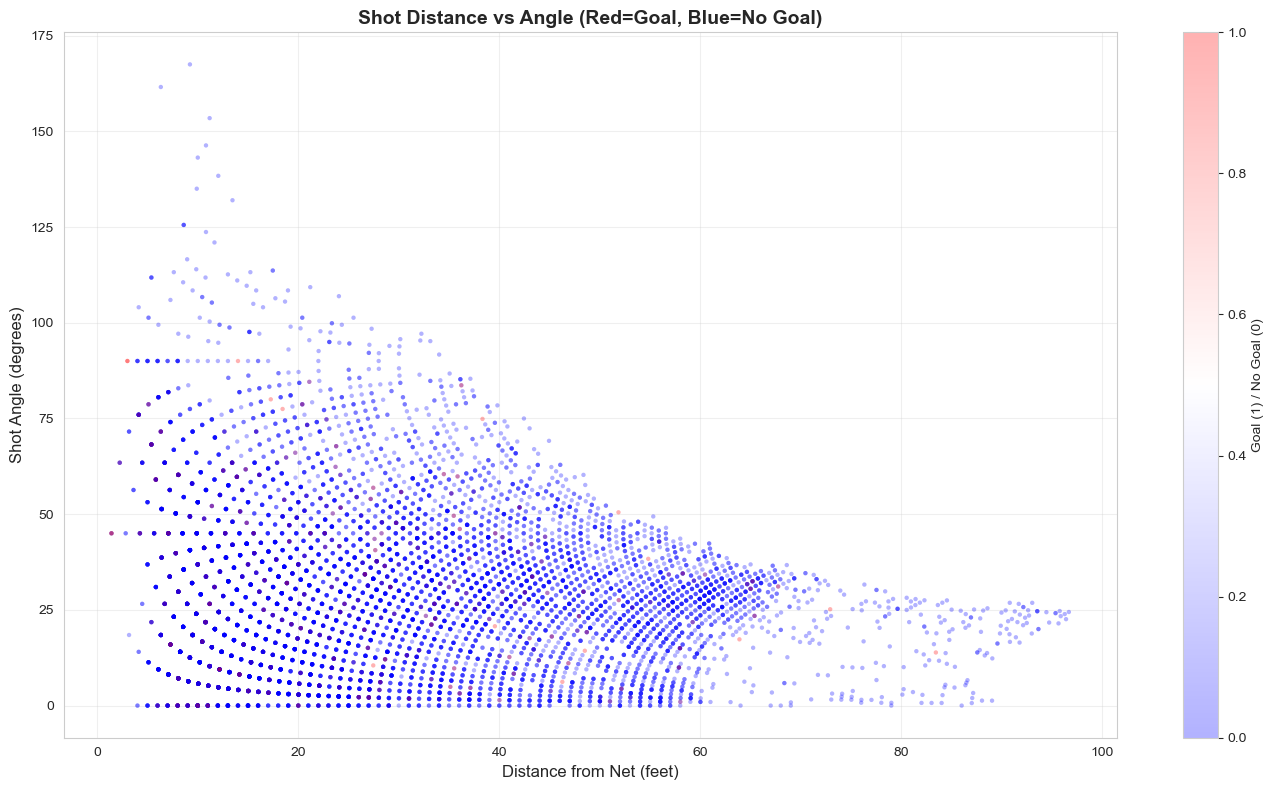

In [11]:
fig, ax = plt.subplots(figsize = (14, 8))

# Sample data for performance (optional - remove if you want all data points)
sample_size = 10000
if len(df_shots_clean) > sample_size:
    sample_df = df_shots_clean.sample(n = sample_size, random_state = 42)
else:
    sample_df = df_shots_clean

# Scatter plot colored by goal
scatter = ax.scatter(sample_df['distance'], sample_df['angle'].abs(),
                     c = sample_df['is_goal'], cmap = 'bwr',
                     alpha = 0.3, s = 10, edgecolors = 'none')

ax.set_xlabel('Distance from Net (feet)', fontsize = 12)
ax.set_ylabel('Shot Angle (degrees)', fontsize = 12)
ax.set_title('Shot Distance vs Angle (Red=Goal, Blue=No Goal)', fontsize = 14, fontweight = 'bold')
ax.grid(True, alpha = 0.3)
plt.colorbar(scatter, ax = ax, label = 'Goal (1) / No Goal (0)')

plt.tight_layout()
plt.show()


## Correlation Analysis


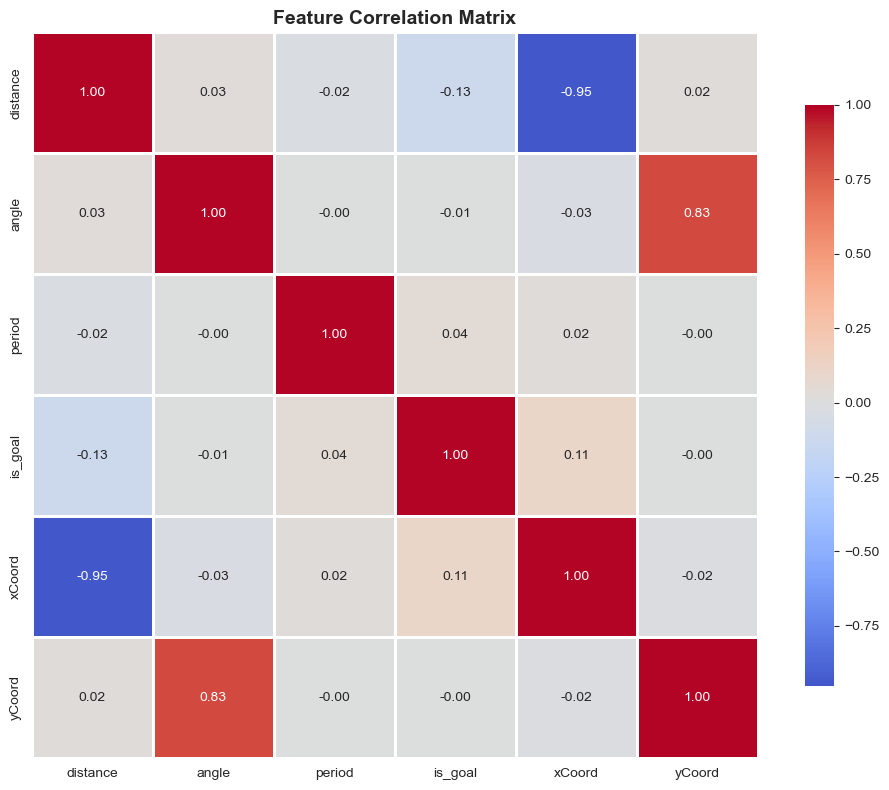


Correlation with Goal:
is_goal     1.000000
xCoord      0.106930
period      0.041822
yCoord     -0.004903
angle      -0.005931
distance   -0.125635
Name: is_goal, dtype: float64


In [12]:
# Select numeric columns for correlation
numeric_cols = ['distance', 'angle', 'period', 'is_goal', 'xCoord', 'yCoord']
corr_data = df_shots_clean[numeric_cols].corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Goal:")
print(corr_data['is_goal'].sort_values(ascending=False))


## Save Data with Basic Features

Save the data with distance and angle features for use in feature engineering notebook.


In [13]:
# Save data with basic features
OUTPUT_FILE = "../../data/processed/shots_with_basic_features.parquet"
df_shots_clean.to_parquet(OUTPUT_FILE, index=False)

print(f"Data with basic features saved to {OUTPUT_FILE}")
print(f"Shape: {df_shots_clean.shape}")


Data with basic features saved to ../../data/processed/shots_with_basic_features.parquet
Shape: (680581, 34)
